# Binary valued data, i.e. on grid-graph $\mathbb{B}_d$-image

In [ ]:
from scipy import interpolate
import numpy as np
import matplotlib.pyplot as plt
import time

import PIL
from matplotlib import image
from matplotlib import pyplot

import condat_tv
import cvxpy as cp

import cv2

import imp

In [ ]:
import multi_binary

In [194]:
imp.reload(multi_binary)

<module 'binary' from '/Users/jonasbresch/Desktop/binary_denoising/binary.py'>

# Segmentation samples

In [62]:
from matplotlib import image
from matplotlib import pyplot

xx = image.imread('cameraman.jpg')
#image = image.imread('reichstag_schwarz.jpeg')
image = cv2.resize(image.imread('mathbuilding.png'), (256,256))
#image = image.imread('brandenburg_gate_2.jpeg')
#image = image.imread('concert_hall_1.jpeg')

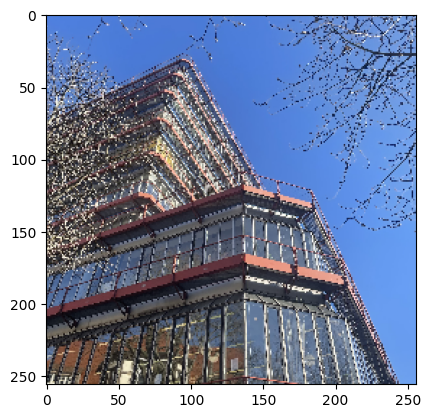

In [63]:
plt.imshow(image)

In [64]:
gimage = 1-image[:,:,0]

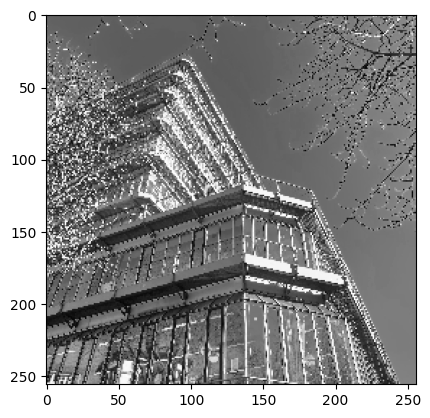

In [66]:
plt.imshow(gimage, cmap='Greys')

In [90]:
d = 10
id = 1/10
gDataimage = np.zeros((d,256,256))
for i in range(256):
    for j in range(256):
        for l in range(d):
            if gimage[i,j] > l*id:
                gDataimage[l,i,j] = 1
gDataimage = 2*gDataimage-1
gNoiseimage = gDataimage + 0.25*np.random.randn(d,256,256)

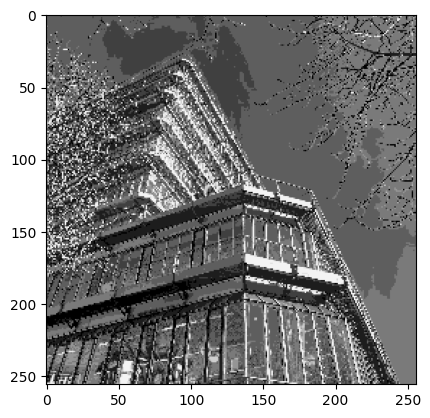

In [91]:
plt.imshow(np.sum(gDataimage,0), cmap='Greys')

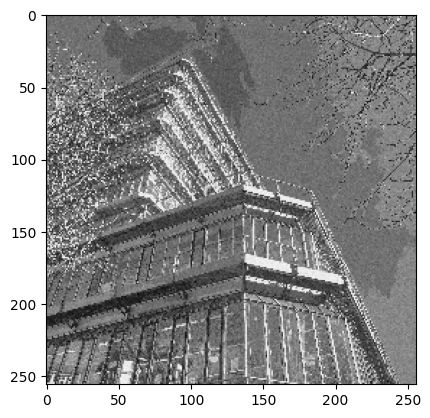

In [92]:
plt.imshow(np.sum(gNoiseimage,0), cmap='Greys')

In [ ]:
qr, gz = multi_binary.ADMM_TV_CUBE_image(gNoiseimage, gDataimage, 0.1, 1, 5, 1, iter=101)

iter. 	| funv-value 		| RMSE 		| MAE 		| spherical-error 	| MioU
-----------------------------------------------------------------------------------------
0  	|  26259.767973260507  	|    1.32e+04  	|    6.03e+04  	|    1.75e-03  	|    9.98e+00
19  	|  40926.77936897582  	|    6.00e+00  	|    2.10e+02  	|    9.83e-05  	|    9.99e+00


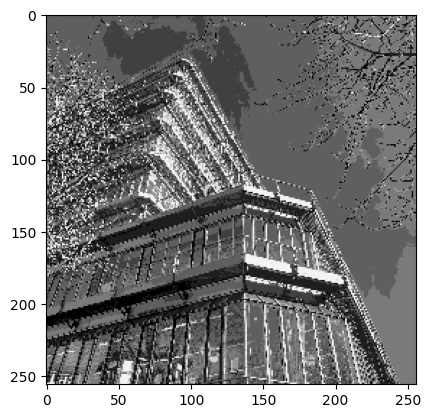

In [99]:
plt.imshow(np.sum(qr,0), cmap='Greys')

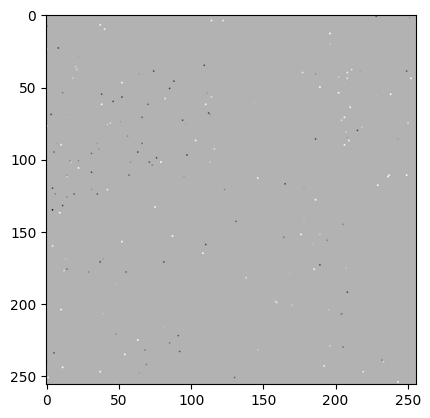

In [100]:
plt.imshow(np.sum(qr,0) - np.sum(gDataimage,0), cmap='Greys')

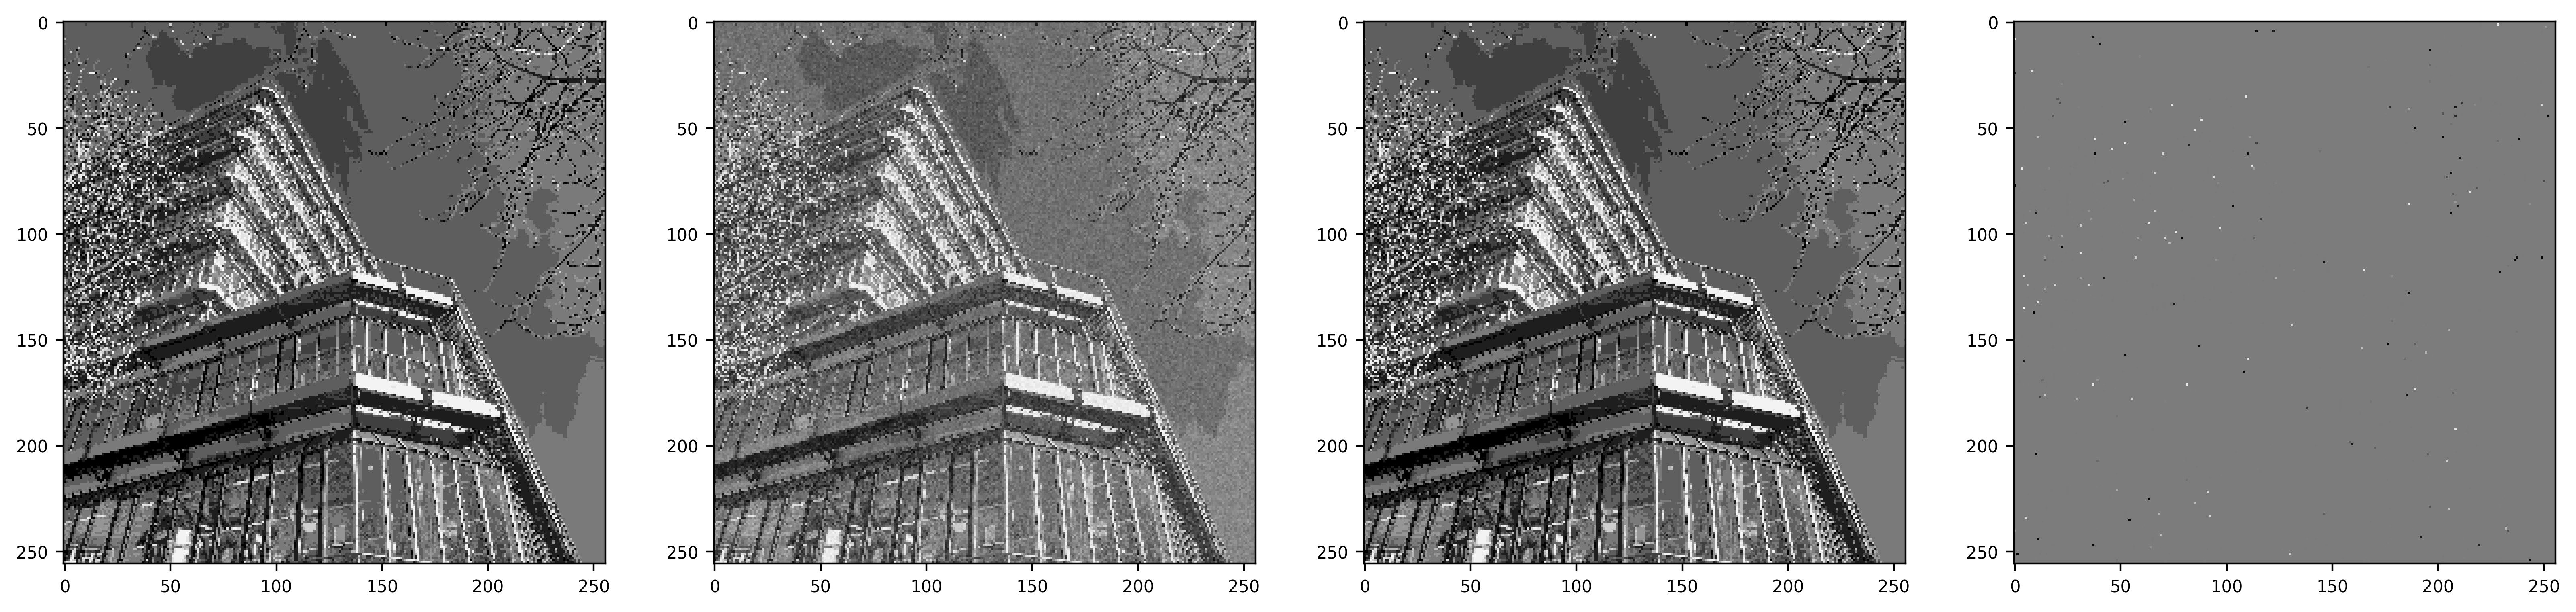

In [ ]:
multi_binary.mulit_qr_code_plt(gDataimage, gNoiseimage, qr)

### Mulit-QR-code denoising

In [ ]:
QRNoise_dd, QRData_dd = multi_binary.multi_qr_code_generator(20,4,0.1,5)

standard deviation : sigma = 0.14142135623730953
standard deviation : sigma = 0.14142135623730953
standard deviation : sigma = 0.14142135623730953
standard deviation : sigma = 0.14142135623730953


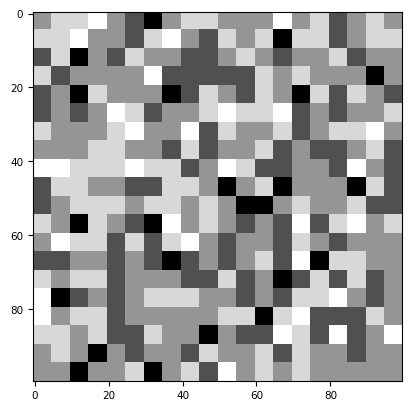

In [126]:
plt.imshow(np.sum(QRData_dd,0), 'Greys')

In [ ]:
qr, gz = multi_binary.ADMM_TV_CUBE_image(QRNoise_dd, QRData_dd, 0.01, 100, 5, 1)

iter. 	| funv-value 		| RMSE 		| MAE 		| spherical-error 	| MioU
-----------------------------------------------------------------------------------------
0  	|  60039.30271723219  	|    5.88e+04  	|    5.94e+04  	|    2.43e-02  	|    6.00e+00
50  	|  15340.74787235954  	|    1.49e+04  	|    2.97e+04  	|    1.22e-02  	|    6.00e+00
100  	|  731.2072296110081  	|    2.91e+02  	|    2.29e+03  	|    1.70e-03  	|    6.00e+00
150  	|  1194.734895791412  	|    9.22e-01  	|    6.98e+00  	|    9.60e-05  	|    6.00e+00
151  	|  1200.1636525671581  	|    0.00e+00  	|    0.00e+00  	|    9.60e-05  	|    6.00e+00


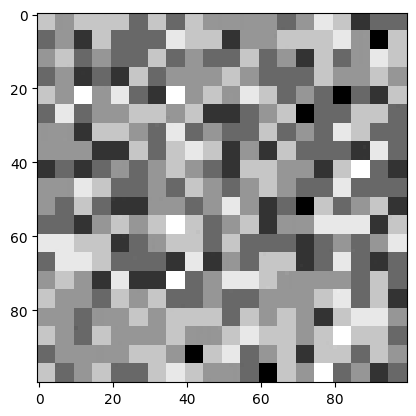

In [40]:
plt.imshow(np.sum(qr,0), 'Greys')

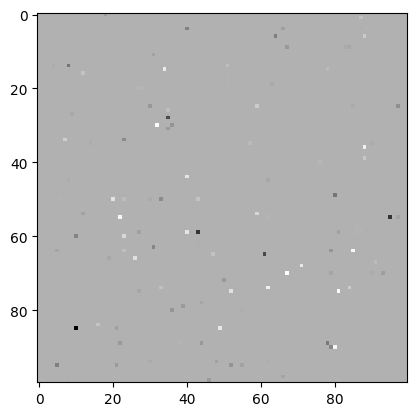

In [42]:
plt.imshow(np.sum(qr,0) - np.sum(QRData_dd,0), 'Greys')

In [ ]:
cQRNoise, cQRData = multi_binary.color_qr_code_generator(20,0.2,5)

In [ ]:
cQRNoiseRGB = multi_binary.cmyk_to_rgb_image(np.transpose((cQRNoise-np.min(cQRNoise))/(np.max(cQRNoise)-np.min(cQRNoise)), (1,2,0)))
# cQRNoiseRGB = multi_binary.cmyk_to_rgb_image(np.transpose(cQRNoise, (1,2,0)))
cQRDataRGB = multi_binary.cmyk_to_rgb_image(np.transpose(cQRData, (1,2,0)))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


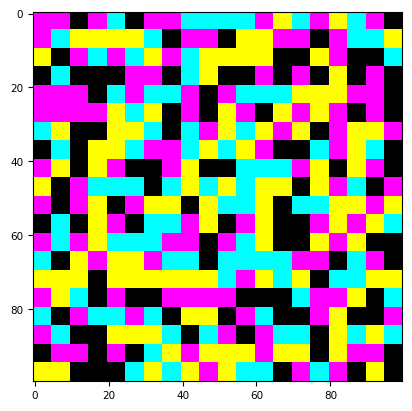

In [72]:
plt.imshow(cQRDataRGB)

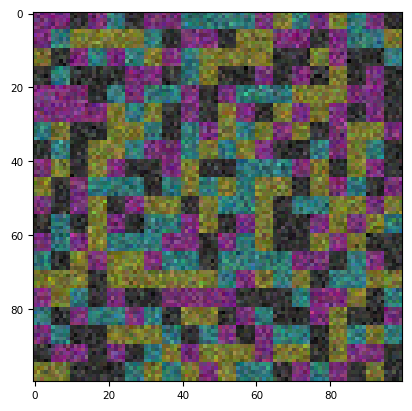

In [73]:
plt.imshow(cQRNoiseRGB/255)

In [ ]:
qr, gz = multi_binary.ADMM_TV_CUBE_image(2*cQRNoise-1, 2*cQRData-1, 0.2, 100, 5, 1, iter=501)

iter. 	| funv-value 		| RMSE 		| MAE 		| spherical-error 	| MioU
-----------------------------------------------------------------------------------------
0  	|  45820.072345592795  	|    3.93e+04  	|    3.97e+04  	|    1.98e-02  	|    4.00e+00
50  	|  19599.086645934844  	|    1.36e+04  	|    2.31e+04  	|    1.17e-02  	|    4.00e+00
100  	|  7537.129159598037  	|    1.99e+03  	|    6.59e+03  	|    4.46e-03  	|    4.00e+00
150  	|  6204.8076739370135  	|    3.47e+02  	|    1.18e+03  	|    1.85e-03  	|    4.00e+00
200  	|  6172.103159503728  	|    9.51e+01  	|    2.78e+02  	|    9.42e-04  	|    4.00e+00
250  	|  6222.349709758475  	|    4.80e+01  	|    1.05e+02  	|    6.32e-04  	|    4.00e+00
300  	|  6248.663005077291  	|    3.41e+01  	|    5.80e+01  	|    4.95e-04  	|    4.00e+00
350  	|  6263.112797480359  	|    2.84e+01  	|    3.88e+01  	|    4.24e-04  	|    4.00e+00
400  	|  6270.125903677189  	|    2.59e+01  	|    3.12e+01  	|    3.82e-04  	|    4.00e+00
450  	|  6273.996565741207

In [ ]:
cQRSolRGB = multi_binary.cmyk_to_rgb_image(np.transpose((1+qr)/2, (1,2,0)))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


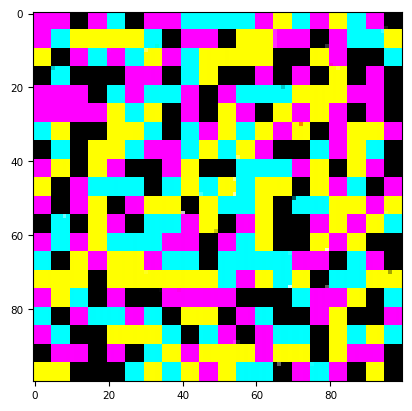

In [82]:
plt.imshow(cQRSolRGB/255)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


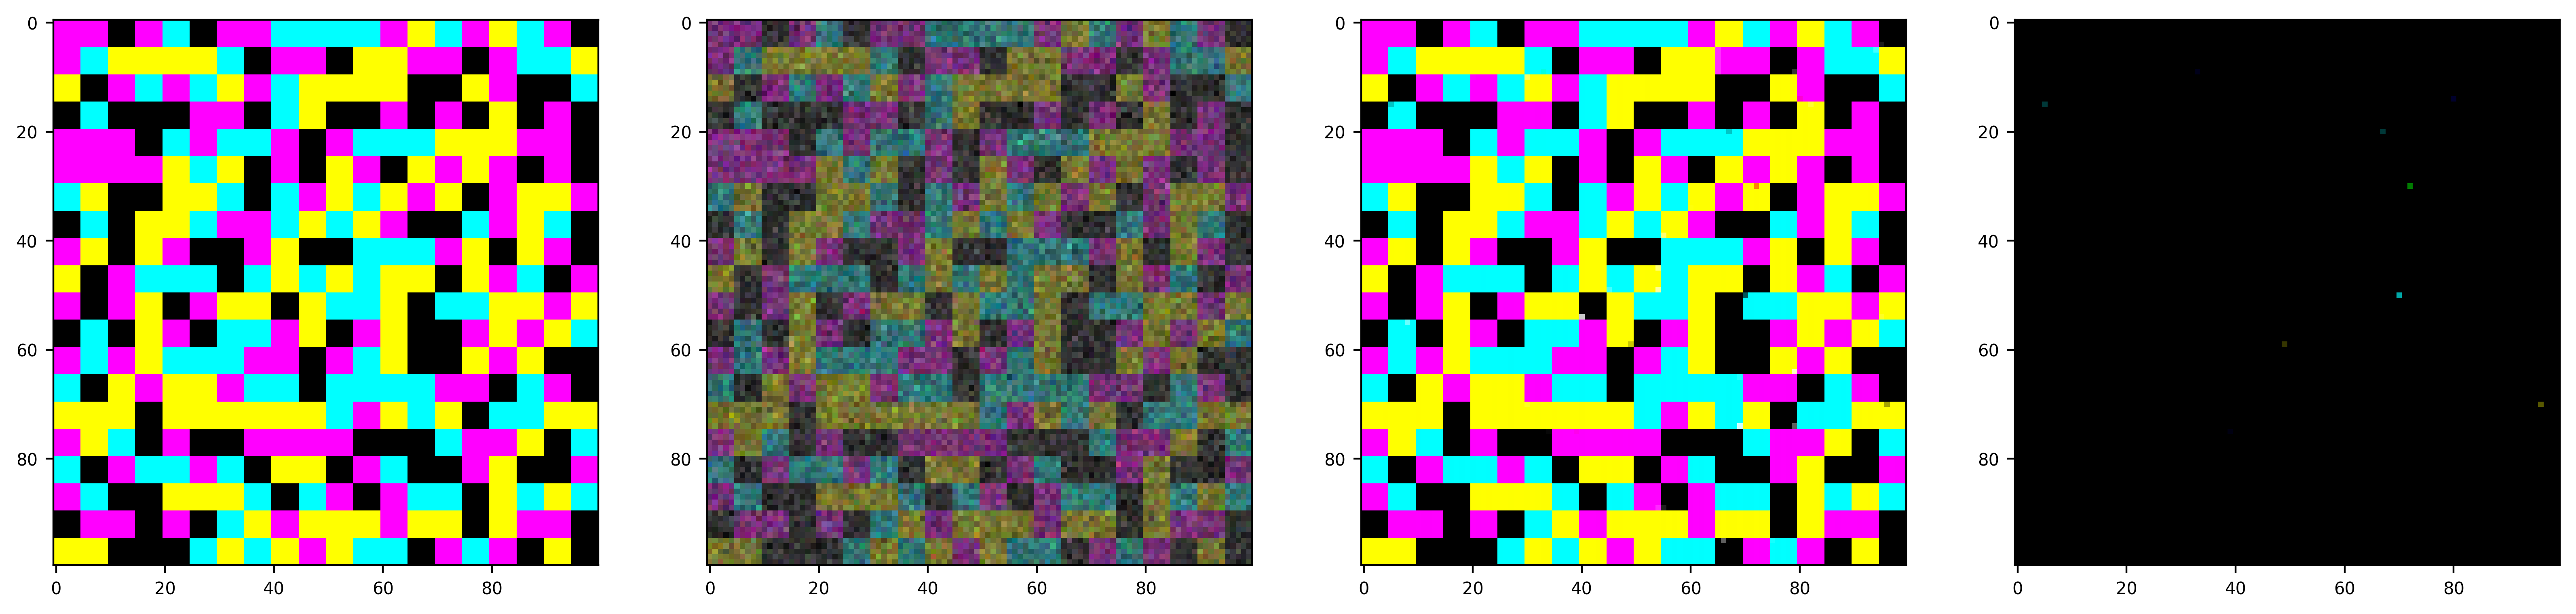

In [ ]:
multi_binary.color_qr_code_plt(cQRDataRGB/255, cQRNoiseRGB/255, cQRSolRGB/255)
plt.savefig('color_qr_code_sig=0.20.pdf', dpi=100)

### Multi-color RGB QR-codes

In [ ]:
QRNoise, QRData = multi_binary.multi_qr_code_generator(20, 3, 0.5, 10)

standard deviation : sigma = 0.7071067811865476
standard deviation : sigma = 0.7071067811865476
standard deviation : sigma = 0.7071067811865476


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


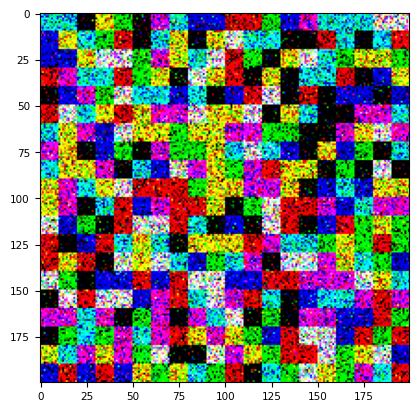

In [200]:
plt.imshow(np.transpose(QRNoise, (1,2,0)))

In [ ]:
qr, gz = multi_binary.ADMM_TV_CUBE_image(QRNoise, QRData, [1.2,1.2,1.2], 1, 1, iter=101)      # 0.5, 100, 1

iter. 	| funv-value 		| RMSE 		| MAE 		| spherical-error 	| MioU
-----------------------------------------------------------------------------------------
0  	|  65269.651946268415  	|    7.63e+03  	|    2.70e+04  	|    2.17e-03  	|    2.99e+00
26  	|  59939.43712422861  	|    3.20e+01  	|    2.56e+02  	|    9.81e-05  	|    2.99e+00


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


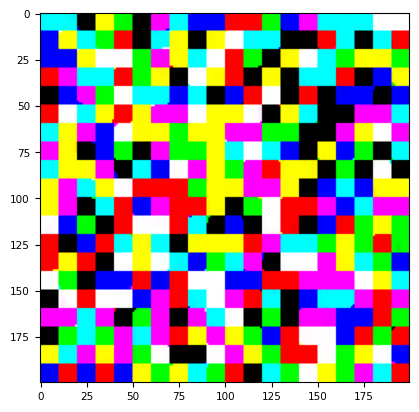

In [214]:
plt.imshow(np.transpose(qr, (1,2,0)))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


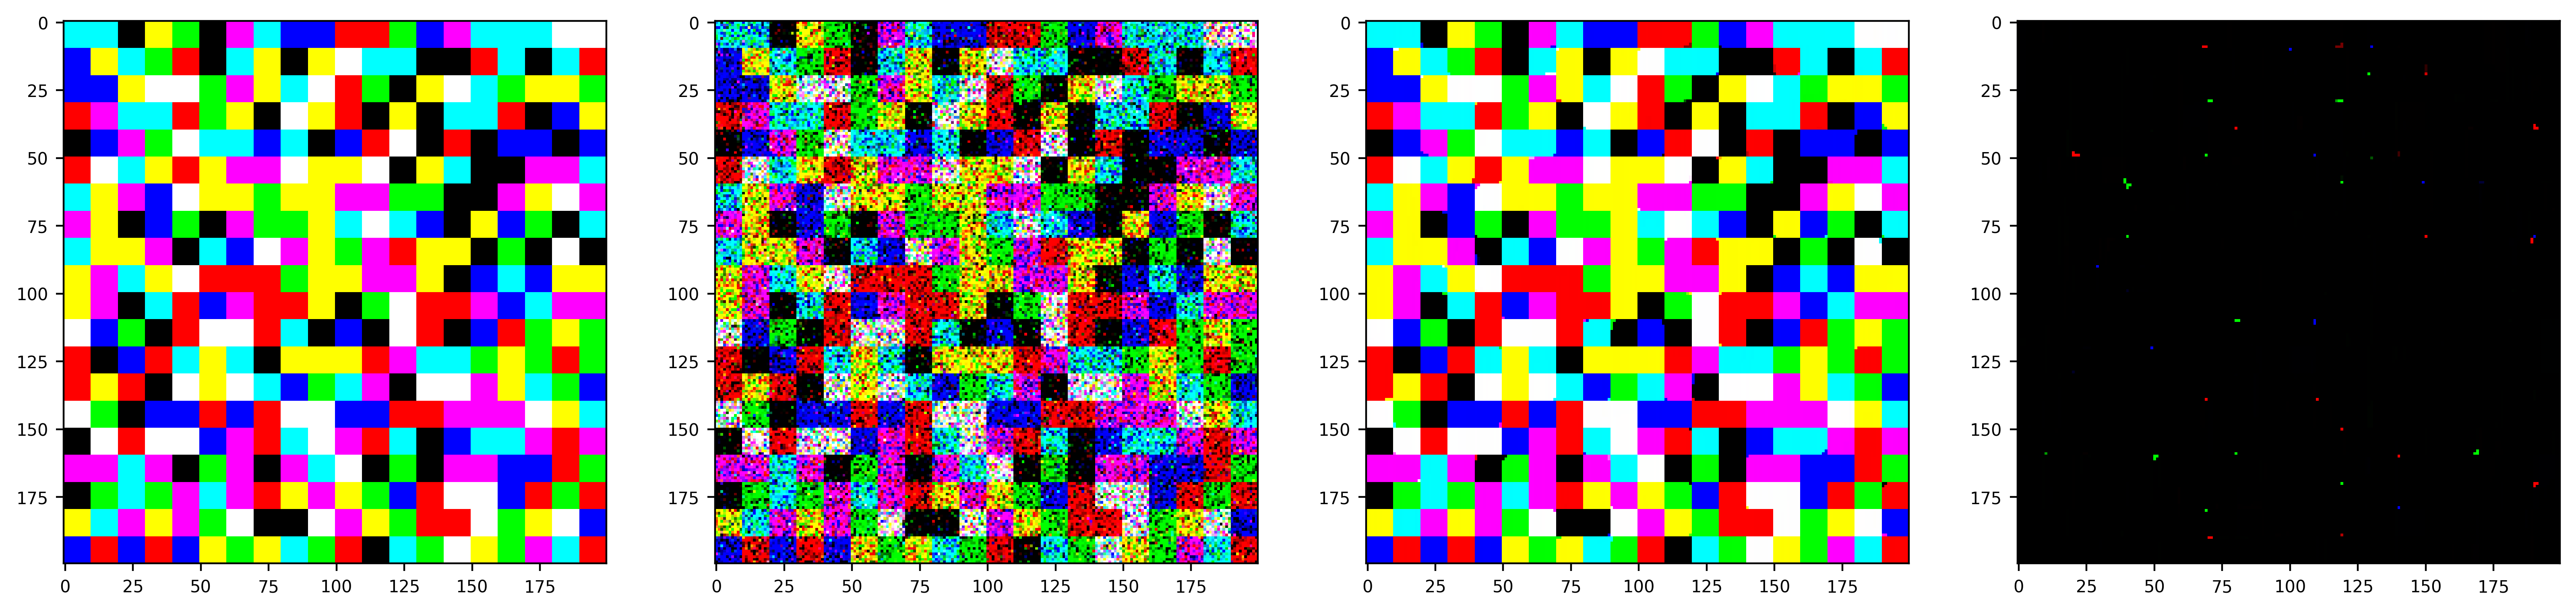

In [ ]:
multi_binary.mulit_qr_code_plt(QRData, QRNoise, qr)
plt.savefig('multi_rgb_qr_0.5.pdf', dpi=100)